# Comparative Evaluation of LLM Models — Electronic Health Record (EHR) Auditor

This notebook compares candidate LLM models (Qwen2.5-3B, Phi-4-mini-instruct e Llama 3.2 3B) using the endpoint already integrated with the system.

**Prerequisites:**
- The system endpoint running locally (LM Studio + your backend)
- Structured ground truth in `data/gabarito.csv`
- Test records in `data/prontuarios.json`


In [29]:
%pip install requests pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Setup and imports

In [30]:
import json
import re
import time
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = DATA_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Producer URL
PRODUCER_URL = "http://localhost:3001"

# Full list of candidate models (general reference for the study)
ALL_MODELS = [
    "qwen2.5-3b-instruct",
    "phi-4-mini-instruct",
    "llama-3.2-3b-instruct",
]

N_REPETITIONS = 1
SEED = 42

# Auditable fields per section.
# NOTE: these section/field keys ("secao_a", "hda", "escala_braden", ...) are
# NOT translated — they must match the exact keys returned by the backend's
# audit_data JSON payload, so changing them would break the lookup below.
AUDITABLE_FIELDS = {
    "secao_a": [
        "diagnostico_internacao",
    ],
    "secao_b_anamnese": [
        "hda", "hd_cid", "ap_app", "af", "exame_fisico", "cd", "criacao_anamnese",
    ],
    "secao_b_evolucao": [
        "hd_cid", "exame_fisico", "procedimentos_condutas_queixas", "frequencia_diaria",
    ],
    "secao_c": [
        "diagnostico_cid", "descricao_procedimento", "descricao_tecnica", "uso_opme",
    ],
    "secao_d_anamnese": [
        "motivo_internacao", "ap_app", "af", "exame_fisico",
        "escala_braden", "escala_morse", "cd", "criacao_anamnese",
    ],
    "secao_d_evolucao": [
        "motivo_internacao", "exame_fisico", "condutas",
        "escala_braden", "escala_morse", "curativo", "criacao_evolucao",
    ],
}

## 2. Load ground truth and test records

The ground truth needs to be in a structured format: one row per (record, field), with the expected label.

Expected format of the `gabarito.csv` file:

| prontuario | secao | campo | esperado |
|---|---|---|---|
| 85826536 | secao_d_evolucao | escala_braden | ausente |
| 85826536 | secao_d_anamnese | ap_app | presente |

Where `esperado` is `presente` (the information is correctly recorded / compliant) or `ausente` (missing/not recorded).


In [31]:
ground_truth = pd.read_csv(DATA_DIR / 'gabarito.csv')
ground_truth['record'] = ground_truth['record'].astype(str).str.strip()

print(f"Total ground truth rows: {len(ground_truth)}")
print(f"Unique fields: {sorted(ground_truth['field'].unique())}")
ground_truth.head()


Total ground truth rows: 253
Unique fields: ['ap_app', 'criacao_anamnese', 'diagnostico_cid', 'escala_braden', 'exame_fisico', 'frequencia_diaria', 'hd_cid', 'hda']


,record,professional_category,record_type,field,failure_description,expected
0,85826536,MEDICINA,Evolução,exame_fisico,Evolução incompleta (sistemas faltando),absent
1,85826536,ENFERMAGEM,Evolução,escala_braden,"Campo ausente na descrição (#HD, Braden, Morse...",absent
2,58907003,MEDICINA,Anamnese,hda,Campo ausente na descrição (#HDA),absent
3,58907004,ENFERMAGEM,Evolução,escala_braden,Campo ausente na descrição (Braden),absent
4,67412841,MEDICINA,Evolução,exame_fisico,Evolução incompleta (sistemas faltando),absent


In [ ]:
N_PATIENTS = 10

with open(DATA_DIR / 'prontuarios.json', encoding='utf-8') as f:
    all_records = json.load(f)

# Only picks patients that exist in the ground truth
ground_truth_pids = set(ground_truth['record'].unique())

unique_records = []
for record_entry in all_records:
    pid = str(record_entry.get('Prontuário', '')).replace('.', '').strip()
    if pid in ground_truth_pids and pid not in unique_records:
        unique_records.append(pid)
        if len(unique_records) == N_PATIENTS:
            break

test_records = [
    r for r in all_records
    if str(r.get('Prontuário', '')).replace('.', '').strip() in unique_records
]

print(f"Sample reduced to: {len(unique_records)} unique records (all in ground truth).")
print(f"Total entries that will be sent to the endpoint: {len(test_records)}")


Sample reduced to: 15 unique records (all in ground truth).
Total entries that will be sent to the endpoint: 142


## 3. Parsing function for the `(IA: ...)` tag

Separates what was resolved by the AI (fallback) from what was already resolved by the rule/regex engine.

In [33]:
def extract_ai_info(value):
    """
    Takes the value of a field (string) returned by the endpoint and splits it into:
    - status: the general label ('conforme', 'não registrado', 'não se aplica', etc.)
    - from_ai: True if the field was resolved by the AI fallback (has an '(IA: ...)' tag)
    - ai_excerpt: the text extracted by the AI, if any
    """
    if value is None:
        return {'status': None, 'from_ai': False, 'ai_excerpt': None}

    value = str(value)
    match = re.search(r'\(IA:\s*(.*?)\)', value)

    if match:
        ai_excerpt = match.group(1).strip()
        status = value[:match.start()].strip()
        return {'status': status, 'from_ai': True, 'ai_excerpt': ai_excerpt}
    else:
        return {'status': value.strip(), 'from_ai': False, 'ai_excerpt': None}


# Quick sanity checks
assert extract_ai_info("conforme (IA: REFERE ALERGIA A DIPIRONA)") == {
    'status': 'conforme', 'from_ai': True, 'ai_excerpt': 'REFERE ALERGIA A DIPIRONA'
}
assert extract_ai_info("Não registrado") == {
    'status': 'Não registrado', 'from_ai': False, 'ai_excerpt': None
}
print("OK - parsing working correctly")


OK - parsing working correctly


## 4. Endpoint call function

Adjust to match the actual payload your endpoint expects. If the endpoint doesn't accept `model_name` as a parameter yet, see the note in the next cell.

In [34]:
PRODUCER_URL = "http://localhost:3001"

# The run_endpoint function, which used to simulate a single synchronous call,
# is no longer needed, since we now process everything in batches via the Producer.
# Kept here only for reference / documentation of the earlier approach.
def run_endpoint(record_id, text, record_type, model_name):
    pass


> **Note:** if the endpoint doesn't accept `model_name` in the payload yet, you have two options:
> 1. Add that parameter in the backend (forwarding it to the LM Studio call) — recommended, avoids manual work.
> 2. Manually change the `MODEL_NAME` constant in the backend and restart the service between each round of `ALL_MODELS`, running this notebook once per model.

## 5. Run all models against all test records

In [35]:
def run_full_evaluation(models, records, n_repetitions=1):
    rows = []

    for model in models:
        print(f"\n=== Running model: {model} ===")
        for repetition in range(n_repetitions):
            print(f"Sending batch to the Producer (repetition {repetition + 1})...")
            start_time = time.time()

            # Builds query params — seed is only included if set
            params = {"model": model}
            if SEED is not None:
                params["seed"] = SEED

            try:
                response = requests.post(
                    f"{PRODUCER_URL}/batches",
                    params=params,
                    json=records
                )
                response.raise_for_status()
            except Exception as e:
                print(f"  [ERROR] Failed to send batch to the Producer: {e}")
                continue

            batch_info = response.json()
            batch_id = batch_info['batch_id']
            jobs = batch_info['jobs']
            print(f"Batch {batch_id} queued with {len(jobs)} unique records. Waiting for the Worker...")

            results_by_record = {}
            pending_jobs = {job['job_id']: job['record_number'] for job in jobs}

            while pending_jobs:
                completed = []
                for job_id, record_id in pending_jobs.items():
                    try:
                        status_response = requests.get(f"{PRODUCER_URL}/jobs/{job_id}/status")
                        if status_response.status_code == 200:
                            body = status_response.json()
                            if body.get("status") == "done":
                                audit_data = body.get("result", {}).get("audit_data", {})
                                results_by_record[record_id] = audit_data
                                completed.append(job_id)
                    except Exception:
                        pass

                for job_id in completed:
                    del pending_jobs[job_id]

                if pending_jobs:
                    time.sleep(5)

            duration = time.time() - start_time
            print(f"Batch for model {model} completed in {duration:.2f} seconds.")

            for record_id, data in results_by_record.items():
                for section, expected_fields in AUDITABLE_FIELDS.items():
                    returned_fields = data.get(section, {})
                    if not isinstance(returned_fields, dict):
                        continue
                    for field in expected_fields:
                        value = returned_fields.get(field)
                        info = extract_ai_info(value)
                        rows.append({
                            'model': model,
                            'repetition': repetition,
                            'record': record_id,
                            'section': section,
                            'field': field,
                            'raw_value': value,
                            'status': info['status'],
                            'from_ai': info['from_ai'],
                            'ai_excerpt': info['ai_excerpt'],
                            'time_seconds': duration / max(1, len(results_by_record)),
                            'execution_error': None,
                        })
    return pd.DataFrame(rows)


In [ ]:
df_raw_batch = run_full_evaluation(ALL_MODELS, test_records, n_repetitions=N_REPETITIONS)

results_path = RESULTS_DIR / 'raw_results.csv'

if results_path.exists():
    df_existing = pd.read_csv(results_path)
    df_existing = df_existing[~df_existing['model'].isin(ALL_MODELS)]
    df_raw = pd.concat([df_existing, df_raw_batch], ignore_index=True)
else:
    df_raw = df_raw_batch

df_raw.to_csv(results_path, index=False)
print(f"Models finalized: {sorted(df_raw['model'].unique())}")
df_raw.head(10)



=== Running model: qwen2.5-3b-instruct ===
Sending batch to the Producer (repetition 1)...
Batch 8a2d5a32-78b2-471f-8cc6-f61f1cb039bb queued with 15 unique records. Waiting for the Worker...


## 6. Filter down to fields resolved by the AI

This is the real basis for comparison — the fields the regex/rule engine couldn't resolve and that fell through to the AI fallback.

In [ ]:
df_ai = df_raw.copy()
df_ai['record'] = df_ai['record'].astype(str).str.strip()
print(f"Total rows for comparison: {len(df_ai)}")
df_ai.head(10)


Total rows for comparison: 93


,model,repetition,record,section,field,raw_value,status,from_ai,ai_excerpt,time_seconds,execution_error
0,qwen2.5-3b-instruct,0,85826536,secao_a,diagnostico_internacao,conforme (IA: Obstrução intestinal por hérnia ...,conforme,True,Obstrução intestinal por hérnia inguinal estra...,125.193772,None
1,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,hda,conforme,conforme,False,NaN,125.193772,None
2,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,hd_cid,conforme,conforme,False,NaN,125.193772,None
3,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,ap_app,conforme,conforme,False,NaN,125.193772,None
4,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,af,conforme,conforme,False,NaN,125.193772,None
5,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,exame_fisico,conforme (exame físico),conforme (exame físico),False,NaN,125.193772,None
6,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,cd,conforme,conforme,False,NaN,125.193772,None
7,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,criacao_anamnese,conforme,conforme,False,NaN,125.193772,None
8,qwen2.5-3b-instruct,0,85826536,secao_b_evolucao,hd_cid,conforme,conforme,False,NaN,125.193772,None
9,qwen2.5-3b-instruct,0,85826536,secao_b_evolucao,exame_fisico,conforme (exame físico),conforme (exame físico),False,NaN,125.193772,None


## 7. Normalize to a binary classification (present/absent) and join with the ground truth

In [ ]:
# Strips separators from the AI dataframe's record id too, so it matches the ground truth
df_ai['record'] = df_ai['record'].astype(str).str.replace('.', '', regex=False).str.strip()

# Normalizes the free-text `status` into a binary label comparable to the ground truth's `expected`.
# NOTE: this step was missing from the original notebook (it referenced a
# `normalized_classification` column with no code that produced it) — the
# mapping below is a reasonable default based on the status wording described
# in extract_ai_info's docstring. Double-check it against your actual status
# values and adjust the keyword rules if needed.
def normalize_classification(status):
    if status is None:
        return 'not_applicable'
    text = str(status).strip().lower()
    if 'não se aplica' in text or 'nao se aplica' in text:
        return 'not_applicable'
    if 'não conforme' in text or 'nao conforme' in text:
        return 'absent'
    if 'conforme' in text or 'presente' in text:
        return 'present'
    return 'absent'

df_ai['normalized_classification'] = df_ai['status'].apply(normalize_classification)

# Joins with the structured ground truth (matching on record + field)
df_matched = df_ai.merge(
    ground_truth,
    on=['record', 'field'],
    how='left'
)

# Se não está no gabarito, o campo está conforme (present)
df_matched['expected'] = df_matched['expected'].fillna('present')
print(f"Total comparable rows (AI x ground truth): {len(df_matched)}")

# Drops 'not_applicable' cases from the metrics (they are neither TP, FP, TN, nor FN)
df_metrics = df_matched[df_matched['normalized_classification'] != 'not_applicable'].copy()
df_metrics.head(10)



Total comparable rows (AI x ground truth): 93


,model,repetition,record,section,field,raw_value,status,from_ai,ai_excerpt,time_seconds,execution_error,normalized_classification,professional_category,record_type,failure_description,expected
0,qwen2.5-3b-instruct,0,85826536,secao_a,diagnostico_internacao,conforme (IA: Obstrução intestinal por hérnia ...,conforme,True,Obstrução intestinal por hérnia inguinal estra...,125.193772,None,present,NaN,NaN,NaN,present
1,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,hda,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
2,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,hd_cid,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
3,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,ap_app,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
4,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,af,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
5,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,exame_fisico,conforme (exame físico),conforme (exame físico),False,NaN,125.193772,None,present,MEDICINA,Evolução,Evolução incompleta (sistemas faltando),absent
6,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,cd,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
7,qwen2.5-3b-instruct,0,85826536,secao_b_anamnese,criacao_anamnese,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
8,qwen2.5-3b-instruct,0,85826536,secao_b_evolucao,hd_cid,conforme,conforme,False,NaN,125.193772,None,present,NaN,NaN,NaN,present
9,qwen2.5-3b-instruct,0,85826536,secao_b_evolucao,exame_fisico,conforme (exame físico),conforme (exame físico),False,NaN,125.193772,None,present,MEDICINA,Evolução,Evolução incompleta (sistemas faltando),absent


## 8. Quality metrics — Precision, Recall, F1 per model

In [ ]:
quality_summary = []

for model in ALL_MODELS:
    subset = df_metrics[df_metrics['model'] == model].copy()
    if len(subset) == 0:
        continue

    # Métrica de Presença: Se a falha é por estar incompleto ou fora do prazo, o campo existe fisicamente.
    subset['expected_presence'] = subset['expected'].copy()
    mask_incompleto = subset['failure_description'].fillna('').str.contains('incompleta|incompleto|prazo', case=False)
    subset.loc[mask_incompleto, 'expected_presence'] = 'present'

    y_true_audit = subset['expected']
    y_true_presence = subset['expected_presence']
    y_pred = subset['normalized_classification']

    quality_summary.append({
        'model': model,
        'n_samples': len(subset),
        'precision (Qualidade)': precision_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
        'recall (Qualidade)': recall_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
        'f1 (Qualidade)': f1_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
        'precision (Presença)': precision_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
        'recall (Presença)': recall_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
        'f1 (Presença)': f1_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
    })

df_quality_summary = pd.DataFrame(quality_summary)
display(df_quality_summary)


,model,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença)
0,qwen2.5-3b-instruct,30,0.777778,0.875000,0.823529,0.925926,0.892857,0.909091
1,phi-4-mini-instruct,30,0.760000,0.791667,0.775510,0.920000,0.821429,0.867925
2,llama-3.2-3b-instruct,30,0.785714,0.916667,0.846154,0.928571,0.928571,0.928571


### 8.1 Metrics per field (to identify which fields are hardest for each model)

In [ ]:
field_summary = []

for model in ALL_MODELS:
    for field in df_metrics['field'].unique():
        subset = df_metrics[(df_metrics['model'] == model) & (df_metrics['field'] == field)].copy()
        if len(subset) == 0:
            continue

        subset['expected_presence'] = subset['expected'].copy()
        mask_incompleto = subset['failure_description'].fillna('').str.contains('incompleta|incompleto|prazo', case=False)
        subset.loc[mask_incompleto, 'expected_presence'] = 'present'

        y_true_audit = subset['expected']
        y_true_presence = subset['expected_presence']
        y_pred = subset['normalized_classification']

        field_summary.append({
            'model': model,
            'field': field,
            'n_samples': len(subset),
            'precision (Qualidade)': precision_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'recall (Qualidade)': recall_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'f1 (Qualidade)': f1_score(y_true_audit, y_pred, pos_label='present', zero_division=0),
            'precision (Presença)': precision_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
            'recall (Presença)': recall_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
            'f1 (Presença)': f1_score(y_true_presence, y_pred, pos_label='present', zero_division=0),
        })

df_field_summary = pd.DataFrame(field_summary)
df_field_summary.to_csv(RESULTS_DIR / 'quality_metrics_by_field.csv', index=False)
display(df_field_summary.sort_values(['model', 'f1 (Qualidade)']))


,model,field,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença)
43,llama-3.2-3b-instruct,exame_fisico,4,0.0,0.0,0.000000,1.0,1.0,1.000000
48,llama-3.2-3b-instruct,diagnostico_cid,1,0.0,0.0,0.000000,0.0,0.0,0.000000
49,llama-3.2-3b-instruct,descricao_procedimento,1,0.0,0.0,0.000000,0.0,0.0,0.000000
53,llama-3.2-3b-instruct,escala_braden,2,0.0,0.0,0.000000,0.0,0.0,0.000000
38,llama-3.2-3b-instruct,diagnostico_internacao,1,1.0,1.0,1.000000,1.0,1.0,1.000000
39,llama-3.2-3b-instruct,hda,1,1.0,1.0,1.000000,1.0,1.0,1.000000
40,llama-3.2-3b-instruct,hd_cid,2,1.0,1.0,1.000000,1.0,1.0,1.000000
41,llama-3.2-3b-instruct,ap_app,2,1.0,1.0,1.000000,1.0,1.0,1.000000
42,llama-3.2-3b-instruct,af,2,1.0,1.0,1.000000,1.0,1.0,1.000000
44,llama-3.2-3b-instruct,cd,2,1.0,1.0,1.000000,1.0,1.0,1.000000


### 8.2 Confusion matrix per model

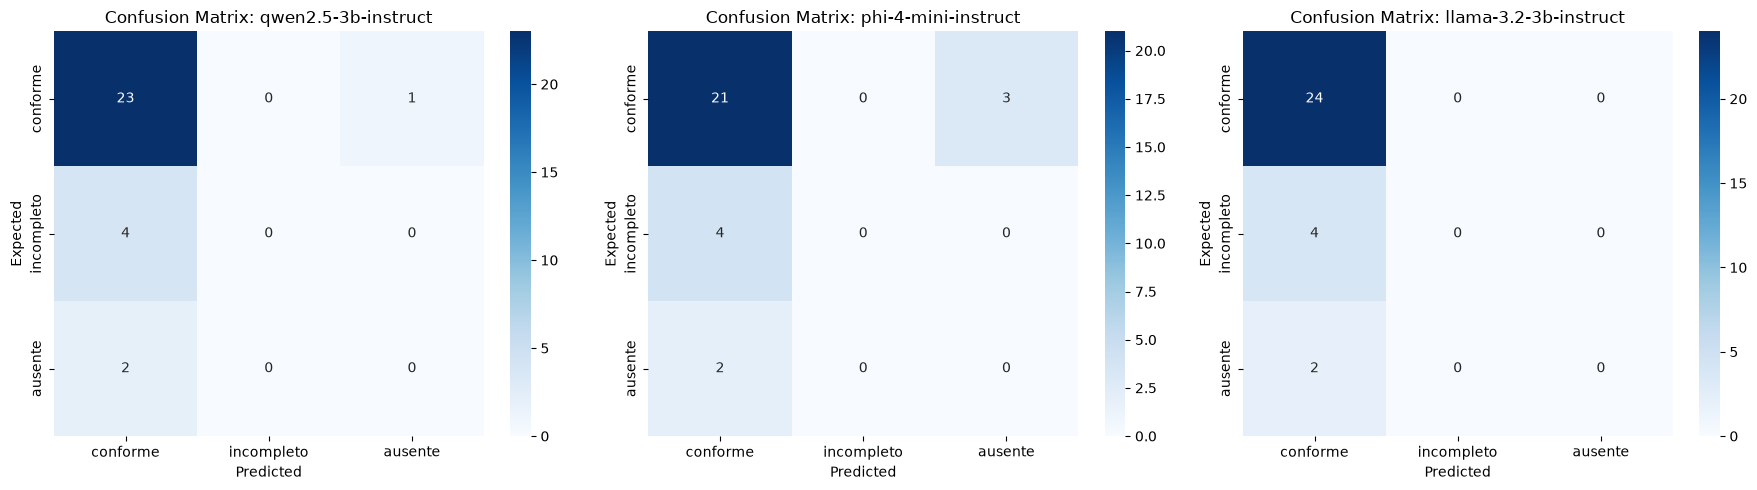

In [ ]:
# Mapeia as 3 classes para o gabarito
def get_expected_3way(row):
    if row['expected'] == 'present':
        return 'conforme'
    desc = str(row['failure_description']).lower()
    if 'incomplet' in desc or 'prazo' in desc:
        return 'incompleto'
    return 'ausente'

df_metrics['expected_3way'] = df_metrics.apply(get_expected_3way, axis=1)

# Mapeia as 3 classes para a predição da IA
def get_predicted_3way(row):
    status = str(row['status']).lower()
    raw = str(row['raw_value']).lower()
    if 'não se aplica' in status: return 'not_applicable' # ignorado
    if 'não' in status and ('incomplet' in raw or 'incomplet' in status): 
        return 'incompleto'
    if 'não' in status: 
        return 'ausente'
    return 'conforme'

df_metrics['predicted_3way'] = df_metrics.apply(get_predicted_3way, axis=1)

# Lista das 3 classes na ordem correta
labels_3way = ['conforme', 'incompleto', 'ausente']

fig, axes = plt.subplots(1, len(ALL_MODELS), figsize=(6 * len(ALL_MODELS), 5))
if len(ALL_MODELS) == 1:
    axes = [axes]

for i, model in enumerate(ALL_MODELS):
    subset = df_metrics[df_metrics['model'] == model]
    
    if len(subset) == 0:
        continue
        
    y_true = subset['expected_3way']
    y_pred = subset['predicted_3way']
    
    cm = confusion_matrix(y_true, y_pred, labels=labels_3way)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=labels_3way, yticklabels=labels_3way)
    axes[i].set_title(f"Confusion Matrix: {model}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Expected")

plt.tight_layout()
plt.show()


## 9. Latency metrics (critical for running on CPU / a notebook without a GPU)

In [ ]:
# Time is measured per endpoint call (all fields for that record), not per individual field
df_times = df_raw.drop_duplicates(subset=['model', 'repetition', 'record'])[
    ['model', 'record', 'time_seconds']
]

latency_summary = df_times.groupby('model')['time_seconds'].agg(
    mean='mean', std='std', min='min', max='max'
).reset_index()

latency_summary.to_csv(RESULTS_DIR / 'latency_metrics.csv', index=False)
latency_summary


,model,mean,std,min,max
0,llama-3.2-3b-instruct,140.130593,NaN,140.130593,140.130593
1,phi-4-mini-instruct,360.444088,NaN,360.444088,360.444088
2,qwen2.5-3b-instruct,125.193772,NaN,125.193772,125.193772


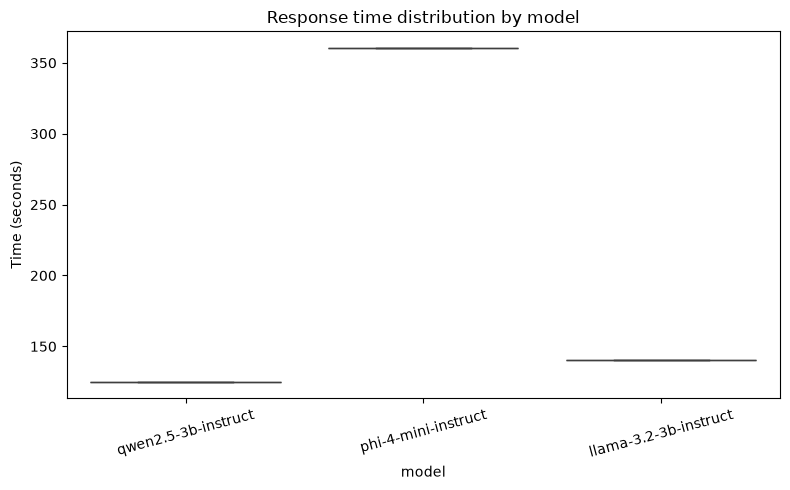

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_times, x='model', y='time_seconds')
plt.title('Response time distribution by model')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latency_boxplot.png', dpi=150)
plt.show()


## 10. Technical error rate per model

Separates execution failures (timeout, invalid JSON, endpoint down) from content errors — important so a model isn't penalized for infrastructure instability.

In [ ]:
error_rate_df = df_raw.groupby('model').apply(
    lambda g: pd.Series({
        'total_calls': g['record'].nunique(),
        'calls_with_error': g[g['execution_error'].notna()]['record'].nunique(),
    })
).reset_index()

error_rate_df['error_rate_pct'] = (error_rate_df['calls_with_error'] / error_rate_df['total_calls'] * 100).round(2)
error_rate_df


,model,total_calls,calls_with_error,error_rate_pct
0,llama-3.2-3b-instruct,1,0,0.0
1,phi-4-mini-instruct,1,0,0.0
2,qwen2.5-3b-instruct,1,0,0.0


## 11. Final consolidated table — summary for the thesis

In [ ]:
final_summary = df_quality_summary.merge(latency_summary, on='model').merge(
    error_rate_df[['model', 'error_rate_pct']], on='model'
)
final_summary = final_summary.round(3)
final_summary.to_csv(RESULTS_DIR / 'final_summary.csv', index=False)
final_summary


,model,n_samples,precision (Qualidade),recall (Qualidade),f1 (Qualidade),precision (Presença),recall (Presença),f1 (Presença),mean,std,min,max,error_rate_pct
0,qwen2.5-3b-instruct,30,0.778,0.875,0.824,0.926,0.893,0.909,125.194,NaN,125.194,125.194,0.0
1,phi-4-mini-instruct,30,0.760,0.792,0.776,0.920,0.821,0.868,360.444,NaN,360.444,360.444,0.0
2,llama-3.2-3b-instruct,30,0.786,0.917,0.846,0.929,0.929,0.929,140.131,NaN,140.131,140.131,0.0


---
## Manual next steps

1. Review `quality_metrics_by_field.csv` to identify which fields perform worst per model
2. Manually validate a sample of the error cases (`normalized_classification != expected`) to confirm whether they are real model failures or issues in the synthetic ground truth
3. Use `final_summary.csv` and the generated charts as the basis for the thesis tables/figures
4. To formally measure consistency/determinism, increase `N_REPETITIONS` to 3-5 and compute the agreement rate between repetitions